# WorldGraph Privacy Provenance

Purpose: visualize the Milestone 12 research workflow for a small WorldGraph, provenance-bearing semantic state, privacy mode demotion and rollup, and BFLD identity-risk gate thresholds.

Run path: install research extras with `uv sync --extra research`, open this notebook, and choose Run All. The cells are deterministic and do not require radio hardware, captured packets, live identity data, or completed `ruview.worldgraph` / `ruview.privacy` implementations.

Fixture / simulated source: inline NumPy fixtures create one room, two WiFi CSI sensors, one person track, one semantic occupancy state, provenance handles for evidence/model/calibration/privacy decision, privacy mode policies, BFLD payload-section sizes, and identity-risk factors. Guarded imports probe `ruview.worldgraph` and `ruview.privacy`; local fallback helpers keep this notebook smoke-testable while Milestone 12 code workers are still in progress.

In [1]:
import math

import numpy as np

try:
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyArrowPatch, Rectangle
except Exception as exc:
    raise RuntimeError('Install the research extra with: uv sync --extra research') from exc

try:
    import ruview.worldgraph as worldgraph_api
except Exception as exc:
    worldgraph_api = None
    WORLDGRAPH_IMPORT_ERROR = exc
else:
    WORLDGRAPH_IMPORT_ERROR = None

try:
    import ruview.privacy as privacy_api
except Exception as exc:
    privacy_api = None
    PRIVACY_IMPORT_ERROR = exc
else:
    PRIVACY_IMPORT_ERROR = None

plt.rcParams.update({
    'figure.figsize': (12, 8),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def has_api(module, *names):
    return module is not None and all(hasattr(module, name) for name in names)


API_IMPORT_STATUS = {
    'ruview.worldgraph': 'api' if has_api(worldgraph_api, 'WorldGraph') else 'fallback',
    'ruview.privacy': 'api' if has_api(privacy_api, 'PrivacyMode') else 'fallback',
}
print(API_IMPORT_STATUS)


{'ruview.worldgraph': 'api', 'ruview.privacy': 'api'}


In [2]:
room_bounds = {'min_e': 0.0, 'min_n': 0.0, 'max_e': 5.0, 'max_n': 4.0}
nodes = {
    'room:1': {
        'kind': 'room',
        'label': 'Room\nliving_room',
        'xy': np.array([2.5, 2.0]),
        'color': '#d9d9d9',
    },
    'sensor:2': {
        'kind': 'sensor',
        'label': 'Sensor A\nWiFi CSI',
        'xy': np.array([0.45, 0.45]),
        'color': '#1f77b4',
    },
    'sensor:3': {
        'kind': 'sensor',
        'label': 'Sensor B\nWiFi CSI',
        'xy': np.array([4.55, 3.45]),
        'color': '#17becf',
    },
    'person:4': {
        'kind': 'person_track',
        'label': 'PersonTrack\ntrack_id=7',
        'xy': np.array([2.9, 2.35]),
        'color': '#ff7f0e',
    },
    'semantic:5': {
        'kind': 'semantic_state',
        'label': 'SemanticState\npresent 0.86',
        'xy': np.array([2.5, 5.15]),
        'color': '#2ca02c',
    },
    'prov:evidence': {
        'kind': 'provenance',
        'label': 'EvidenceRef\nev:csi-a,b',
        'xy': np.array([0.75, 6.45]),
        'color': '#9467bd',
    },
    'prov:model': {
        'kind': 'provenance',
        'label': 'Model\nrfenc-v12',
        'xy': np.array([2.1, 6.65]),
        'color': '#9467bd',
    },
    'prov:calibration': {
        'kind': 'provenance',
        'label': 'Calibration\ncal:00ab',
        'xy': np.array([3.55, 6.65]),
        'color': '#9467bd',
    },
    'prov:privacy': {
        'kind': 'provenance',
        'label': 'Privacy\nPrivateHome/Restricted',
        'xy': np.array([4.85, 6.45]),
        'color': '#9467bd',
    },
}

edges = [
    ('sensor:2', 'room:1', 'observes', 0.92),
    ('sensor:3', 'room:1', 'observes', 0.89),
    ('sensor:2', 'person:4', 'observes', 0.78),
    ('sensor:3', 'person:4', 'observes', 0.81),
    ('person:4', 'room:1', 'located_in', None),
    ('semantic:5', 'room:1', 'derived_from', None),
    ('semantic:5', 'person:4', 'derived_from', None),
    ('semantic:5', 'prov:evidence', 'provenance', None),
    ('semantic:5', 'prov:model', 'provenance', None),
    ('semantic:5', 'prov:calibration', 'provenance', None),
    ('semantic:5', 'prov:privacy', 'provenance', None),
]

semantic_provenance = {
    'evidence': ['ev:csi-a:0012', 'ev:csi-b:0012'],
    'model_version': 'rfenc-v12-sim',
    'calibration_version': 'cal:00000000000000ab',
    'privacy_decision': 'PrivateHome/Restricted',
}

print({'worldgraph_source': API_IMPORT_STATUS['ruview.worldgraph'], 'provenance': semantic_provenance})


{'worldgraph_source': 'api', 'provenance': {'evidence': ['ev:csi-a:0012', 'ev:csi-b:0012'], 'model_version': 'rfenc-v12-sim', 'calibration_version': 'cal:00000000000000ab', 'privacy_decision': 'PrivateHome/Restricted'}}


In [3]:
privacy_classes = {'Raw': 0, 'Derived': 1, 'Anonymous': 2, 'Restricted': 3}
privacy_modes = {
    'RawResearch': {'class': 'Raw', 'actions': ['Allow']},
    'PrivateHome': {'class': 'Anonymous', 'actions': ['SuppressIdentity', 'DropRaw']},
    'EnterpriseAnonymous': {'class': 'Anonymous', 'actions': ['SuppressIdentity', 'DropRaw', 'AggregateOnly']},
    'CareWithConsent': {'class': 'Derived', 'actions': ['Allow']},
    'StrictNoIdentity': {'class': 'Restricted', 'actions': ['SuppressIdentity', 'ReduceResolution', 'DropRaw', 'AggregateOnly']},
}

def demote_one(class_name):
    by_value = {value: key for key, value in privacy_classes.items()}
    return by_value[min(privacy_classes[class_name] + 1, privacy_classes['Restricted'])]


def observation_allowed(mode, target_kind):
    actions = set(privacy_modes[mode]['actions'])
    if 'SuppressIdentity' in actions and target_kind == 'person_track':
        return False
    if 'AggregateOnly' in actions and target_kind in {'person_track', 'semantic_state'}:
        return False
    return True


def rollup_for_mode(mode):
    observe_edges = [(src, dst) for src, dst, rel, _ in edges if rel == 'observes']
    denied = []
    allowed = 0
    suppressed = []
    for src, dst in observe_edges:
        if observation_allowed(mode, nodes[dst]['kind']):
            allowed += 1
        else:
            denied.append((src, dst))
            if dst not in suppressed:
                suppressed.append(dst)
    return {'mode': mode, 'allowed_pairs': allowed, 'denied_pairs': denied, 'suppressed_nodes': suppressed}


rollups = [rollup_for_mode(mode) for mode in privacy_modes]
base_mode = 'PrivateHome'
base_class = privacy_modes[base_mode]['class']
contradiction_flag = True
effective_class = demote_one(base_class) if contradiction_flag else base_class

risk_factors = {
    'separability': np.array([0.25, 0.70, 0.78, 0.88, 0.93, 0.96, 0.98, 0.99]),
    'stability': np.array([0.45, 0.82, 0.84, 0.88, 0.94, 0.97, 0.98, 0.99]),
    'consistency': np.array([0.70, 0.86, 0.90, 0.92, 0.95, 0.98, 0.99, 0.99]),
    'confidence': np.array([0.88, 0.88, 0.90, 0.93, 0.97, 0.98, 0.99, 1.00]),
}
risk_scores = np.prod(np.vstack(list(risk_factors.values())), axis=0)

def gate_action(score):
    if score < 0.5:
        return 'Accept'
    if score < 0.7:
        return 'PredictOnly'
    if score < 0.9:
        return 'Reject'
    return 'Recalibrate'


gate_actions = np.array([gate_action(score) for score in risk_scores], dtype=object)

payload_sections = ['angle_matrix', 'csi_delta', 'amplitude_proxy', 'phase_proxy']
payload_sizes = {
    'Raw/Derived': np.array([48, 24, 18, 18]),
    'Anonymous': np.array([0, 0, 18, 18]),
    'Restricted': np.array([0, 0, 0, 0]),
}

summary = {
    'privacy_source': API_IMPORT_STATUS['ruview.privacy'],
    'base_mode': base_mode,
    'base_class': base_class,
    'effective_class': effective_class,
    'max_risk': round(float(np.max(risk_scores)), 3),
    'recalibrate_frames': int(np.sum(gate_actions == 'Recalibrate')),
}
print(summary)


{'privacy_source': 'api', 'base_mode': 'PrivateHome', 'base_class': 'Anonymous', 'effective_class': 'Restricted', 'max_risk': 0.97, 'recalibrate_frames': 2}


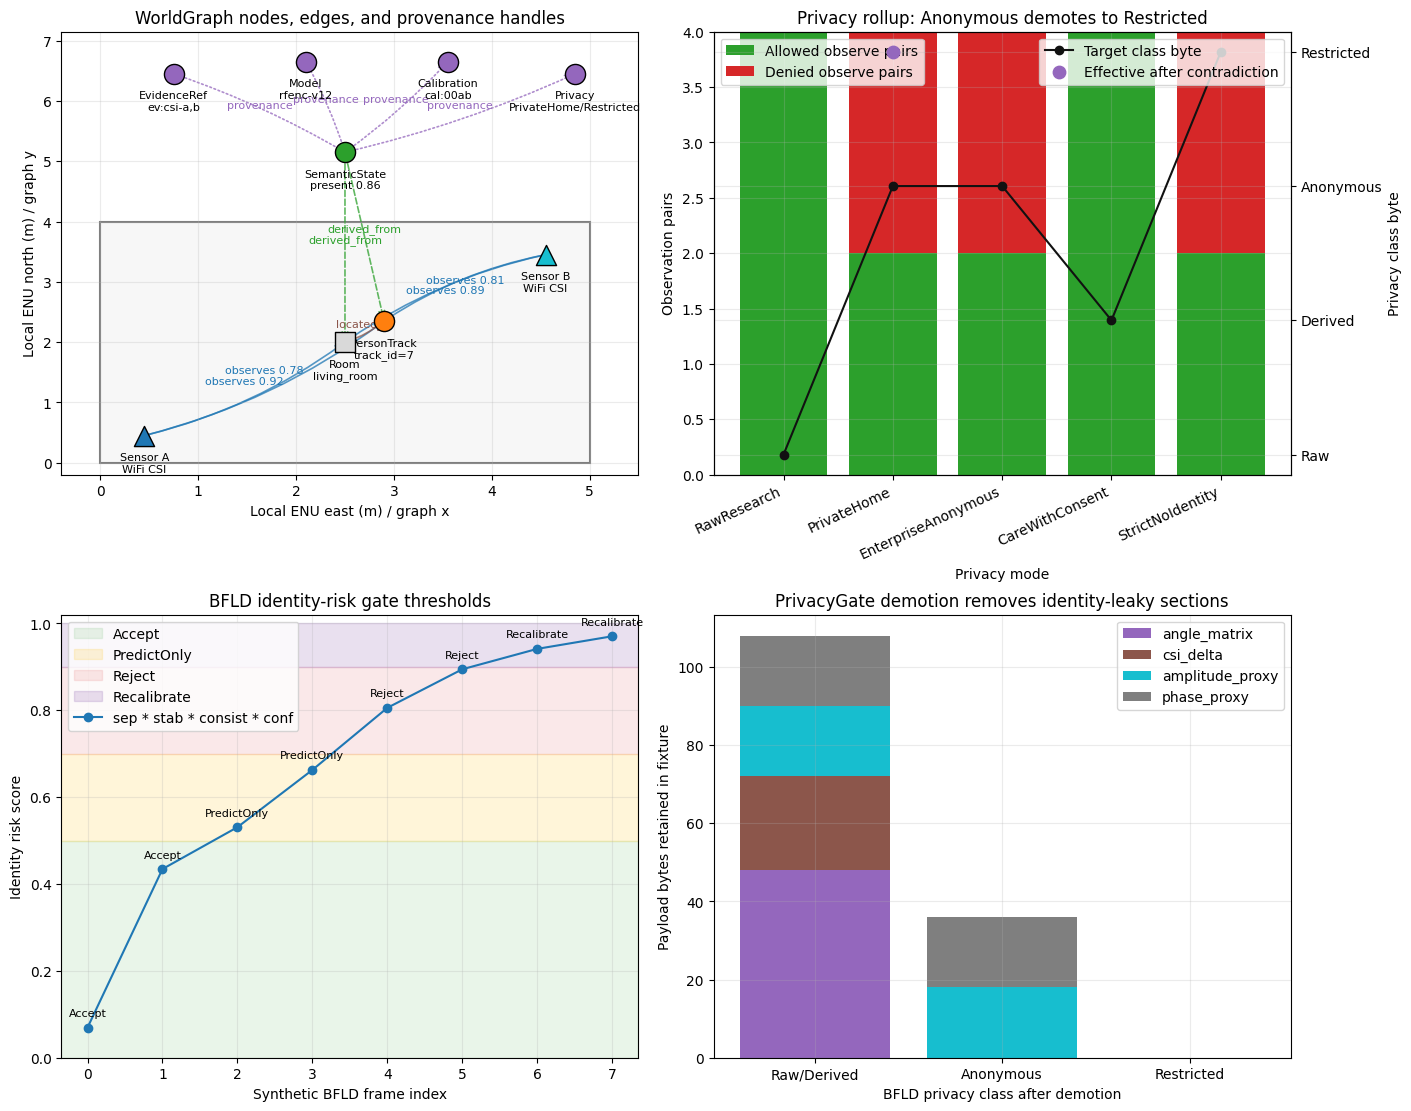

In [4]:
def draw_arrow(ax, src, dst, label, color='#555555', linestyle='-', alpha=0.9, curve=0.0):
    start = nodes[src]['xy']
    end = nodes[dst]['xy']
    patch = FancyArrowPatch(
        start,
        end,
        arrowstyle='->',
        mutation_scale=10,
        linewidth=1.2,
        color=color,
        linestyle=linestyle,
        alpha=alpha,
        connectionstyle=f'arc3,rad={curve}',
    )
    ax.add_patch(patch)
    mid = (start + end) / 2.0
    ax.text(mid[0], mid[1] + 0.08, label, fontsize=8, color=color, ha='center')


fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)

ax = axes[0, 0]
ax.add_patch(Rectangle(
    (room_bounds['min_e'], room_bounds['min_n']),
    room_bounds['max_e'] - room_bounds['min_e'],
    room_bounds['max_n'] - room_bounds['min_n'],
    facecolor='#f7f7f7',
    edgecolor='#7f7f7f',
    linewidth=1.5,
))
edge_style = {
    'observes': ('#1f77b4', '-', 0.10),
    'located_in': ('#8c564b', '-', -0.10),
    'derived_from': ('#2ca02c', '--', 0.00),
    'provenance': ('#9467bd', ':', 0.05),
}
for src, dst, rel, quality in edges:
    color, linestyle, curve = edge_style[rel]
    label = f'{rel} {quality:.2f}' if quality is not None else rel
    draw_arrow(ax, src, dst, label, color=color, linestyle=linestyle, alpha=0.75, curve=curve)
for node_id, node in nodes.items():
    x, y = node['xy']
    marker = 's' if node['kind'] == 'room' else '^' if node['kind'] == 'sensor' else 'o'
    ax.scatter([x], [y], s=210, marker=marker, color=node['color'], edgecolor='black', zorder=5)
    ax.text(x, y - 0.28, node['label'], ha='center', va='top', fontsize=8)
ax.set_xlim(-0.4, 5.5)
ax.set_ylim(-0.2, 7.15)
ax.set_xlabel('Local ENU east (m) / graph x')
ax.set_ylabel('Local ENU north (m) / graph y')
ax.set_title('WorldGraph nodes, edges, and provenance handles')

ax = axes[0, 1]
mode_names = [rollup['mode'] for rollup in rollups]
allowed = np.array([rollup['allowed_pairs'] for rollup in rollups])
denied = np.array([len(rollup['denied_pairs']) for rollup in rollups])
x = np.arange(len(mode_names))
ax.bar(x, allowed, color='#2ca02c', label='Allowed observe pairs')
ax.bar(x, denied, bottom=allowed, color='#d62728', label='Denied observe pairs')
ax.set_xticks(x)
ax.set_xticklabels(mode_names, rotation=25, ha='right')
ax.set_xlabel('Privacy mode')
ax.set_ylabel('Observation pairs')
ax.set_title(f'Privacy rollup: {base_class} demotes to {effective_class}')
ax.legend(loc='upper left')
class_y = [privacy_classes[privacy_modes[mode]['class']] for mode in mode_names]
ax2 = ax.twinx()
ax2.plot(x, class_y, color='#111111', marker='o', label='Target class byte')
ax2.scatter([mode_names.index(base_mode)], [privacy_classes[effective_class]], color='#9467bd', s=80, zorder=5, label='Effective after contradiction')
ax2.set_ylabel('Privacy class byte')
ax2.set_yticks(list(privacy_classes.values()))
ax2.set_yticklabels(list(privacy_classes.keys()))
ax2.legend(loc='upper right')

ax = axes[1, 0]
frames = np.arange(len(risk_scores))
ax.axhspan(0.0, 0.5, color='#2ca02c', alpha=0.10, label='Accept')
ax.axhspan(0.5, 0.7, color='#ffbf00', alpha=0.15, label='PredictOnly')
ax.axhspan(0.7, 0.9, color='#d62728', alpha=0.10, label='Reject')
ax.axhspan(0.9, 1.0, color='#4b0082', alpha=0.12, label='Recalibrate')
ax.plot(frames, risk_scores, marker='o', color='#1f77b4', label='sep * stab * consist * conf')
for idx, action in enumerate(gate_actions):
    ax.annotate(action, (frames[idx], risk_scores[idx]), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8)
ax.set_xlabel('Synthetic BFLD frame index')
ax.set_ylabel('Identity risk score')
ax.set_ylim(0, 1.02)
ax.set_title('BFLD identity-risk gate thresholds')
ax.legend(loc='upper left')

ax = axes[1, 1]
class_labels = list(payload_sizes)
bottom = np.zeros(len(class_labels))
section_colors = ['#9467bd', '#8c564b', '#17becf', '#7f7f7f']
for section_idx, section in enumerate(payload_sections):
    values = np.array([payload_sizes[label][section_idx] for label in class_labels])
    ax.bar(class_labels, values, bottom=bottom, color=section_colors[section_idx], label=section)
    bottom += values
ax.set_xlabel('BFLD privacy class after demotion')
ax.set_ylabel('Payload bytes retained in fixture')
ax.set_title('PrivacyGate demotion removes identity-leaky sections')
ax.legend(loc='upper right')

plt.show()


In [5]:
print('Semantic provenance tuple')
for key, value in semantic_provenance.items():
    print(f'- {key}: {value}')

print('\nPrivacy rollups')
for rollup in rollups:
    suppressed = ', '.join(rollup['suppressed_nodes']) or 'none'
    print(f"- {rollup['mode']}: allowed={rollup['allowed_pairs']} denied={len(rollup['denied_pairs'])} suppressed={suppressed}")

print('\nBFLD gate decisions')
for idx, (score, action) in enumerate(zip(risk_scores, gate_actions)):
    print(f'- frame={idx} risk={score:.3f} action={action}')


Semantic provenance tuple
- evidence: ['ev:csi-a:0012', 'ev:csi-b:0012']
- model_version: rfenc-v12-sim
- calibration_version: cal:00000000000000ab
- privacy_decision: PrivateHome/Restricted

Privacy rollups
- RawResearch: allowed=4 denied=0 suppressed=none
- PrivateHome: allowed=2 denied=2 suppressed=person:4
- EnterpriseAnonymous: allowed=2 denied=2 suppressed=person:4
- CareWithConsent: allowed=4 denied=0 suppressed=none
- StrictNoIdentity: allowed=2 denied=2 suppressed=person:4

BFLD gate decisions
- frame=0 risk=0.069 action=Accept
- frame=1 risk=0.434 action=Accept
- frame=2 risk=0.531 action=PredictOnly
- frame=3 risk=0.663 action=PredictOnly
- frame=4 risk=0.806 action=Reject
- frame=5 risk=0.894 action=Reject
- frame=6 risk=0.941 action=Recalibrate
- frame=7 risk=0.970 action=Recalibrate


Expected interpretation: the graph should show sensors observing both the room and person track, the person located in the room, and the semantic state tied back to evidence/model/calibration/privacy provenance. PrivateHome starts at Anonymous, then a contradiction-style trust flag demotes the effective class to Restricted. Modes that suppress identity deny sensor-to-person observations, aggregate-only modes suppress per-entity observations, identity risk crosses PredictOnly/Reject/Recalibrate thresholds as factors become more separable and stable, and BFLD demotion monotonically removes identity-leaky payload sections.

Limitations: this notebook is a deterministic visual fixture, not a completed WorldGraph, BFLD parser, privacy registry, witness verifier, or RF identity system. It uses local fallback dictionaries because the Python `ruview.worldgraph` and `ruview.privacy` namespaces may not be implemented yet. The plotted policy is diagnostic and local-only; it does not emit raw BFI/CSI, persist identity embeddings, verify BLAKE3 attestation chains, recompute CRC bytes, or claim production privacy compliance.